In [44]:
from natasha import (
    Segmenter,
    MorphVocab,
    
    NewsEmbedding,
    NewsMorphTagger,
    NewsSyntaxParser,
    NewsNERTagger,
    
    PER,
    NamesExtractor,

    Doc
)


segmenter = Segmenter()
morph_vocab = MorphVocab()

emb = NewsEmbedding()
morph_tagger = NewsMorphTagger(emb)
syntax_parser = NewsSyntaxParser(emb)
ner_tagger = NewsNERTagger(emb)

names_extractor = NamesExtractor(morph_vocab)

text = 'Посол Израиля на Украине Йоэль Лион признался, что пришел в шок, узнав о решении властей Львовской области объявить 2019 год годом лидера запрещенной в России Организации украинских националистов (ОУН) Степана Бандеры. Свое заявление он разместил в Twitter. «Я не могу понять, как прославление тех, кто непосредственно принимал участие в ужасных антисемитских преступлениях, помогает бороться с антисемитизмом и ксенофобией. Украина не должна забывать о преступлениях, совершенных против украинских евреев, и никоим образом не отмечать их через почитание их исполнителей», — написал дипломат. 11 декабря Львовский областной совет принял решение провозгласить 2019 год в регионе годом Степана Бандеры в связи с празднованием 110-летия со дня рождения лидера ОУН (Бандера родился 1 января 1909 года). В июле аналогичное решение принял Житомирский областной совет. В начале месяца с предложением к президенту страны Петру Порошенко вернуть Бандере звание Героя Украины обратились депутаты Верховной Рады. Парламентарии уверены, что признание Бандеры национальным героем поможет в борьбе с подрывной деятельностью против Украины в информационном поле, а также остановит «распространение мифов, созданных российской пропагандой». Степан Бандера (1909-1959) был одним из лидеров Организации украинских националистов, выступающей за создание независимого государства на территориях с украиноязычным населением. В 2010 году в период президентства Виктора Ющенко Бандера был посмертно признан Героем Украины, однако впоследствии это решение было отменено судом. '
doc = Doc(text)
doc

Doc(text='Посол Израиля на Украине Йоэль Лион признался, чт...)

In [45]:
import csv
with open('news.csv', 'r') as file:
    news = csv.DictReader(file)
    corpus = [Doc(line['text']) for line in news]

: 

: 

In [ ]:
for line in corpus:
    line.segment(segmenter)
    line.tag_morph(morph_tagger)
print(corpus[0])


Doc(text='В 1930-е годы Советский Союз охватила лихорадка —..., tokens=[...], sents=[...])


In [ ]:
stop_morph = {'SCONJ', 'PUNCT', 'ADP', 'COMP', 'NPRO', 'PREP', 'CONJ', 'PRED', 'PRCL', 'INTJ','CCONJ', 'PRON', 'ADV'}

In [ ]:
def preprocessing(line):
    for token in line.tokens:
        token.lemmatize(morph_vocab)
    return [word.lemma for word in line.tokens if word.pos not in stop_morph]
corpus = list(map(preprocessing, corpus))



In [ ]:
1 +2

3

In [ ]:
corpus_uni = set()
for line in corpus:
    corpus_uni |= set(line)


In [ ]:
corpus_uni

{'пройда',
 'motorola',
 'руденский',
 'леван',
 'ретрокинотеатр',
 'полушарие',
 'тернер-смит',
 '2.29',
 'эрса',
 'лженаука',
 'грациозный',
 'мальфи',
 'узловой',
 'axel',
 'беркутовец',
 'норт-чарлстон',
 'onerepublic',
 '2,38',
 'танг',
 'заммит',
 'раскопав',
 'keylogger',
 'парка',
 'кустурица',
 '644',
 'пьются',
 'среднеанглийский',
 'многообразие',
 'страны-победитель',
 'гербен',
 'нюша',
 'погибнуть',
 'жолдак',
 'хилл',
 'акард',
 'дезадаптация',
 'шашанк',
 'самовозвыситься',
 'натыкаюсь',
 'кочанов',
 'обадий',
 'pfizer',
 'информбезопасность',
 'цзюня',
 'повнимательнее',
 'котельная',
 'сотрясала',
 'праздный',
 'гнилостный',
 'асо',
 'онлайн-саммит',
 'бирюса',
 'стрэтэм-хай-роуд',
 'дарио',
 'пересмотреть',
 'канатный',
 'marché',
 'переменный',
 'уоллистон',
 'кастанер',
 'мон-де-марсан',
 '141',
 'обделить',
 'ввозные',
 'людовой',
 'удержать',
 'логический',
 '85-87',
 'аль-яум',
 '54-d',
 'нутрия',
 'автономия',
 'абрикосовый',
 'парикмахерам',
 'металлургический

In [ ]:
import tqdm


In [ ]:
basis = {elem : i for i,elem in enumerate(corpus_uni)}
dim = len(basis)
matrix = []
for line in tqdm.tqdm(corpus):
    vec = [0] * dim
    for word in line:
        vec[basis[word]] += 1
    matrix.append(vec)

    

100%|██████████| 21673/21673 [00:24<00:00, 895.93it/s] 


In [ ]:
len(basis)

104401

In [ ]:
def cosin_near(vec1, vec2):
    num = 0
    norsum1 = 0
    norsum2 = 0
    for i in range(len(vec1)):
        num += vec1[i] * vec2[i]
        norsum1 += vec1[i] ** 2
        norsum2 += vec2[i] ** 2
    norsum1 **= 0.5
    norsum2 **= 0.5
    return num / (norsum2 * norsum1)
print(cosin_near(matrix[0], matrix[1]))
cos_max = [0, -1]
simi = []
for i, vec in tqdm.tqdm(enumerate(matrix)):
    if i == 0: continue
    cos = cosin_near(matrix[0], vec)
    if cos > cos_max[1]:
        cos_max = [i, cos]
print(*corpus[0])
print(*corpus[cos_max[0]])


0.18238546275973636


21673it [03:17, 109.67it/s]


1930-й год советский союз охватить лихорадка десятилетие бурный индустриализация греметь сообщение новый трудовой подвиг простой народ построение коммунизм светлый будущее первый стать шахтер донбасс алексей стаханов 85 год установить рекорд добыча уголь смена и следующий утро проснуться знаменитый весь мир его одаривать квартира машина возить союз стать любимец сталин итог не выдержать слава спиться фамилия стаханов дать название движение трудовик превратиться нарицательный продолжить существовать живой витрина коммунизм материал лента ру история легенда советский труд начаться шахта центральный-ирмин донбасс 1935 год советский власть запустить второй пятилетка проводить политика ускоренный индустриализация пытаться завет владимир ленин догнать перегнать развить капиталистический страна отстать экономический план распад российский империя препятствие этот путь быть низкий производительность труд советский рабочий угольный промышленность ее повышение мешать сам способ добыча многие про

In [ ]:
similarities = []
for i, vec in tqdm.tqdm(enumerate(matrix)):
    if i == 0: continue
    cos = cosin_near(matrix[0], vec)
    similarities.append(cos)


21673it [03:12, 112.37it/s]


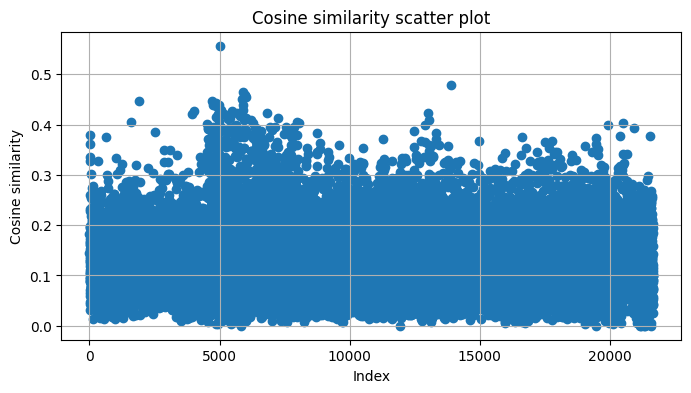

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# пример: близость одного объекта к другим
similarities = np.array(similarities)

x = np.arange(len(similarities))

plt.figure(figsize=(8, 4))

plt.scatter(x, similarities)

plt.xlabel('Index')

plt.ylabel('Cosine similarity')

plt.title('Cosine similarity scatter plot')

plt.grid(True)

plt.show()

In [ ]:
i = int(input())
print(i)

1
